# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Data represents 17 campaigns

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
columns = df.select_dtypes(include='object').columns
for column in columns:
    print(f'****** {column} ******')
    print(df[column].value_counts(normalize=True))

****** job ******
job
admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
unknown          0.008012
Name: proportion, dtype: float64
****** marital ******
marital
married     0.605225
single      0.280859
divorced    0.111974
unknown     0.001942
Name: proportion, dtype: float64
****** education ******
education
university.degree      0.295426
high.school            0.231014
basic.9y               0.146766
professional.course    0.127294
basic.4y               0.101389
basic.6y               0.055647
unknown                0.042027
illiterate             0.000437
Name: proportion, dtype: float64
****** default ******
default
no         0.791201
unknown    0.208726
yes        0.000073
Name: proportion, dtype: float64
****** housing ******
housing
yes       

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

***Business objective*** of this task is to find the best model that can explain the success of the bank marketing campaigns and the attributes that lead to the campaign's success

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

***Data Preparation 1***

Dropping following 2 columns:
1. **duration**
   : as it is mainly used for benchmarking purposes and there is specific guideline saying this attribute should not be used outside of this context
3. **poutcome**
   : previous outcome. Dropping this mainly because it is not providing a lot of information as more than 86% of the information is nonexistant. The breakdown of the different values for this attribute is below:

        nonexistent    0.863431
        failure        0.103234
        success        0.033335

In [6]:
df_bank = df.drop(['duration', 'poutcome'], axis=1)
df_bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  emp.var.rate    41188 non-null  float64
 14  cons.price.idx  41188 non-null  float64
 15  cons.conf.idx   41188 non-null  float64
 16  euribor3m       41188 non-null  float64
 17  nr.employed     41188 non-null 

***Data Prepration 2*** 

There are unknown values for each of the attributes which do not provide any information. Additionally, the proportion of these rows are comparatively quite small. Drop the rows which have 'unknown' values for 'job' and 'marital' columns. There is added advantage with this as some of these columns will become binary resuting in complexity (fewer features)

In [8]:
df_bank_clean = df_bank.loc[(df['job'] != 'unknown') &
                            (df['marital'] != 'unknown') &
                            (df['housing'] != 'unknown') &
                            (df['loan'] != 'unknown')] 

df_bank_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39803 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             39803 non-null  int64  
 1   job             39803 non-null  object 
 2   marital         39803 non-null  object 
 3   education       39803 non-null  object 
 4   default         39803 non-null  object 
 5   housing         39803 non-null  object 
 6   loan            39803 non-null  object 
 7   contact         39803 non-null  object 
 8   month           39803 non-null  object 
 9   day_of_week     39803 non-null  object 
 10  campaign        39803 non-null  int64  
 11  pdays           39803 non-null  int64  
 12  previous        39803 non-null  int64  
 13  emp.var.rate    39803 non-null  float64
 14  cons.price.idx  39803 non-null  float64
 15  cons.conf.idx   39803 non-null  float64
 16  euribor3m       39803 non-null  float64
 17  nr.employed     39803 non-null  floa

In [9]:
df_bank_clean['default'].value_counts()

default
no         31587
unknown     8213
yes            3
Name: count, dtype: int64

***Data Preparation 3***

map unknown values in default to 'no' with assumption that defaulted accounts are important and would definitely be recorded as 'yes'. This is a corner case as the number of 'yes' values is quite small (0.000075). Perhaps a candidate to drop this column


In [10]:
df_bank_clean = df_bank_clean.copy()
df_bank_clean['default'] = df_bank_clean['default'].map(lambda x: 'no' if x == 'unknown' else x)

In [11]:
df_bank_clean['default'].value_counts(normalize=True)

default
no     0.999925
yes    0.000075
Name: proportion, dtype: float64

In [12]:
df_bank_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39803 entries, 0 to 41187
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             39803 non-null  int64  
 1   job             39803 non-null  object 
 2   marital         39803 non-null  object 
 3   education       39803 non-null  object 
 4   default         39803 non-null  object 
 5   housing         39803 non-null  object 
 6   loan            39803 non-null  object 
 7   contact         39803 non-null  object 
 8   month           39803 non-null  object 
 9   day_of_week     39803 non-null  object 
 10  campaign        39803 non-null  int64  
 11  pdays           39803 non-null  int64  
 12  previous        39803 non-null  int64  
 13  emp.var.rate    39803 non-null  float64
 14  cons.price.idx  39803 non-null  float64
 15  cons.conf.idx   39803 non-null  float64
 16  euribor3m       39803 non-null  float64
 17  nr.employed     39803 non-null  floa

In [13]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer

In [14]:
education_order = [
    'illiterate',
    'basic.4y',
    'basic.6y',
    'basic.9y',
    'unknown',
    'high.school',
    'professional.course',
    'university.degree'
]

transformer = make_column_transformer((OneHotEncoder(drop='if_binary', sparse_output=False), 
                                       ['job', 
                                        'marital', 
                                        'default', 
                                        'housing', 
                                        'loan', 
                                        'contact', 
                                        'month', 
                                        'day_of_week',
                                        'y']),
                               (OrdinalEncoder(categories=[education_order]), ['education']),
                                remainder='passthrough')
t_data = transformer.fit_transform(df_bank_clean)
feature_names = [feature.split('__')[1] for feature in transformer.get_feature_names_out()]
df_bank_clean = pd.DataFrame(t_data, columns=feature_names)



In [15]:
df_bank_clean.rename(columns={'y_yes':'y'}, inplace=True)

In [16]:
df_bank_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39803 entries, 0 to 39802
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_admin.         39803 non-null  float64
 1   job_blue-collar    39803 non-null  float64
 2   job_entrepreneur   39803 non-null  float64
 3   job_housemaid      39803 non-null  float64
 4   job_management     39803 non-null  float64
 5   job_retired        39803 non-null  float64
 6   job_self-employed  39803 non-null  float64
 7   job_services       39803 non-null  float64
 8   job_student        39803 non-null  float64
 9   job_technician     39803 non-null  float64
 10  job_unemployed     39803 non-null  float64
 11  marital_divorced   39803 non-null  float64
 12  marital_married    39803 non-null  float64
 13  marital_single     39803 non-null  float64
 14  default_yes        39803 non-null  float64
 15  housing_yes        39803 non-null  float64
 16  loan_yes           398

In [17]:
df_bank_clean['y'].value_counts(normalize=True)

y
0.0    0.88727
1.0    0.11273
Name: proportion, dtype: float64

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X, y = df_bank_clean.drop('y', axis=1), df_bank_clean['y']
X.head()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,56.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,5.0,57.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,5.0,37.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,40.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,5.0,56.0,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y)
X_train = X_train.values
X_test = X_test.values
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((26668, 43), (26668,), (13135, 43), (13135,))

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

***Baseline***

Use the basic majority class proportion as baseline, i.e. if we randomly guess the class based on the proportion of the classes, we would get 87% success. So the trained classifier models should beat at least this baseline which is ~88%

normalized value_counts of y column:
    
    no     0.88727
    yes    0.11273
    

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from time import time

In [22]:
lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('lr', LogisticRegression())])
lr_start_time = time()
lr_pipe.fit(X_train, y_train)
lr_end_time = time()
lr_train_time = lr_end_time - lr_start_time

### Problem 9: Score the Model

What is the accuracy of your model?

In [23]:
lr_train_accuracy = lr_pipe.score(X_train, y_train)
lr_test_accuracy = lr_pipe.score(X_test, y_test)
lr_train_time, lr_train_accuracy, lr_test_accuracy

(0.05486798286437988, 0.9008549572521374, 0.8992767415302626)

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [25]:
classifiers = [LogisticRegression(), KNeighborsClassifier(), DecisionTreeClassifier(), SVC()]
model = ['LogisticRegression', 'KNearestNeighbors', 'DecisionTree', 'SVM']
train_time = []
train_accuracy = []
test_accuracy = []

for classifier in classifiers:
    pipe = Pipeline([('scaler', StandardScaler()), 
                    ('classifier', classifier)])
    start_time = time()
    pipe.fit(X_train, y_train)
    end_time = time()
    train_time.append(end_time - start_time)
    train_accuracy.append(pipe.score(X_train, y_train))
    test_accuracy.append(pipe.score(X_test, y_test))

train_time, train_accuracy, test_accuracy

([0.03511762619018555,
  0.0046231746673583984,
  0.09229516983032227,
  12.068195819854736],
 [0.9008549572521374,
  0.9129293535323234,
  0.9952752362381881,
  0.9089545522723864],
 [0.8992767415302626,
  0.8893033878949372,
  0.8440807004187286,
  0.897830224590788])

In [26]:
model_df = pd.DataFrame({'Model': model,
                         'Train Time': train_time,
                         'Train Accuracy': train_accuracy,
                         'Test Accuracy': test_accuracy})
#model_df = model_df.set_index('Model')
model_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,LogisticRegression,0.035118,0.900855,0.899277
1,KNearestNeighbors,0.004623,0.912929,0.889303
2,DecisionTree,0.092295,0.995275,0.844081
3,SVM,12.068196,0.908955,0.897830


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

**Note**

In addition to accuracy we will also track ROC-AUC and precision-recall as other metrics to evaluate the models. For the classifiers it is important to look at the FPR and TPR to see how effective the models are

In [27]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import numpy as np

In [28]:
def DisplayRocAndPrecisionRecallCurve(estimator, estimator_name):
    plt.figure(figsize=(8,6))
    fig, ax = plt.subplots(1, 2)
    RocCurveDisplay.from_estimator(estimator, X_test, y_test, ax=ax[0])
    ax[0].set_title(f' ROC for {estimator_name}')
    ax[0].set_xlabel('FPR')
    ax[0].set_ylabel('TPR')

    PrecisionRecallDisplay.from_estimator(estimator, X_test, y_test, ax=ax[1])
    ax[1].set_title(f'Precision Recall for {estimator_name}')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')

    plt.tight_layout()
    plt.show()

In [29]:
# grid search across 'penalty' and 'C' values for logistic regression
lgr_params = {'lgr__penalty': ['l1', 'l2'],
              'lgr__solver': ['liblinear'],
              'lgr__C': [0.001, 0.01, 0.1]}
              

In [30]:
lgr_pipe = Pipeline([('scaler', StandardScaler()),
                     ('lgr', LogisticRegression(random_state=42, max_iter=10_000))])
lgr_grid = GridSearchCV(lgr_pipe, param_grid=lgr_params, cv=5)
lgr_grid_start_time = time()
lgr_grid.fit(X_train, y_train)
lgr_grid_end_time = time()

In [31]:
lgr_grid_train_time = lgr_grid_end_time - lgr_grid_start_time
lgr_grid_train_accuracy = lgr_grid.best_estimator_.score(X_train, y_train)
lgr_grid_test_accuracy = lgr_grid.best_estimator_.score(X_test, y_test)

lgr_grid_roc_auc = float(roc_auc_score(y_test, lgr_grid.best_estimator_.predict_proba(X_test)[:, 1]))

print(lgr_grid.best_params_)
lgr_grid_train_time, lgr_grid_train_accuracy, lgr_grid_test_accuracy, lgr_grid_roc_auc

{'lgr__C': 0.1, 'lgr__penalty': 'l2', 'lgr__solver': 'liblinear'}


(2.953176975250244, 0.9007424628768561, 0.898515416825276, 0.7886340937499385)

<Figure size 800x600 with 0 Axes>

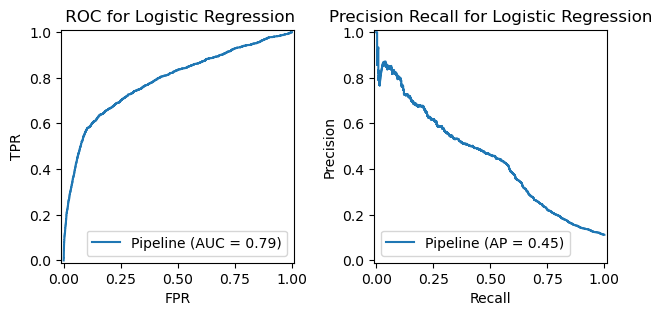

In [32]:
DisplayRocAndPrecisionRecallCurve(lgr_grid.best_estimator_, 'Logistic Regression')

In [33]:
#Decision Tree Classifier

dtree_params = {
         'dtree__max_depth': range(2,11),
         'dtree__min_samples_split': [2, 4, 6],
         'dtree__criterion': ['gini', 'entropy', 'log_loss'],
         'dtree__min_samples_leaf': [1, 2, 3]
         }

In [ ]:
dtree_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('dtree', DecisionTreeClassifier())])
dtree_grid = GridSearchCV(dtree_pipe, param_grid=dtree_params, cv=5)
dtree_start_time = time()
dtree_grid.fit(X_train, y_train)
dtree_end_time = time()

In [ ]:
dtree_grid_train_time = dtree_end_time - dtree_start_time
dtree_grid_train_accuracy = dtree_grid.best_estimator_.score(X_train, y_train)
dtree_grid_test_accuracy = dtree_grid.best_estimator_.score(X_test, y_test)
dtree_grid_roc_auc_score = float(roc_auc_score(y_test, dtree_grid.best_estimator_.predict_proba(X_test)[:, 1]))

print(dtree_grid.best_params_)
dtree_grid_train_time, dtree_grid_train_accuracy, dtree_grid_test_accuracy, dtree_grid_roc_auc_score

In [ ]:
DisplayRocAndPrecisionRecallCurve(dtree_grid.best_estimator_, 'Decision Tree')

In [ ]:
# nearest neighbor classifier

knn_params = {'knn__n_neighbors': list(range(1,30,2))}

In [ ]:
knn_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('knn', KNeighborsClassifier())])
knn_grid = GridSearchCV(knn_pipe, param_grid=knn_params, cv=5)
knn_start_time = time()
knn_grid.fit(X_train, y_train)
knn_end_time = time()

In [ ]:
knn_grid_train_time = knn_end_time - knn_start_time
knn_grid_train_accuracy = knn_grid.best_estimator_.score(X_train, y_train)
knn_grid_test_accuracy = knn_grid.best_estimator_.score(X_test, y_test)
knn_grid_roc_auc_score = float(roc_auc_score(y_test, knn_grid.best_estimator_.predict_proba(X_test)[:,1]))
print(knn_grid.best_params_)
knn_grid_train_time, knn_grid_train_accuracy, knn_grid_test_accuracy, knn_grid_roc_auc_score

In [ ]:
DisplayRocAndPrecisionRecallCurve(knn_grid.best_estimator_, 'KNN')

***Important Note***

It took almost 1.5 hours to run the grid search for hyper parameters for svm. 

In [ ]:
# svm
svm_params = {'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid']}

In [ ]:
svm_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('svc', SVC(probability=True))])
svm_grid = GridSearchCV(svm_pipe, param_grid=svm_params, cv=5)
svm_start_time = time()
svm_grid.fit(X_train, y_train)
svm_end_time = time()

In [ ]:
svm_grid_train_time = svm_end_time - svm_start_time
svm_grid_train_accuracy = svm_grid.best_estimator_.score(X_train, y_train)
svm_grid_test_accuracy = svm_grid.best_estimator_.score(X_test, y_test)
svm_grid_roc_auc_score = float((roc_auc_score(y_test, 
                                              svm_grid.best_estimator_.predict_proba(X_test)[:,1])))
print(svm_grid.best_params_)
svm_grid_train_time, svm_grid_train_accuracy, svm_grid_test_accuracy, svm_grid_roc_auc_score

In [ ]:
DisplayRocAndPrecisionRecallCurve(svm_grid.best_estimator_, 'SVM')

**Visualize results to compare models**

1. Visualize to compare test/train accuracies
2. Times for the best models of each classifer
3. Visualize ROC-AUC and precision recall curves


In [ ]:
train_accuracy = [lgr_grid_train_accuracy, dtree_grid_train_accuracy, knn_grid_train_accuracy, svm_grid_train_accuracy]
test_accuracy = [lgr_grid_test_accuracy, dtree_grid_test_accuracy, knn_grid_test_accuracy, svm_grid_test_accuracy]
train_time = [lgr_grid_train_time, dtree_grid_train_time, knn_grid_train_time, svm_grid_train_time]
roc_auc = [lgr_grid_roc_auc, dtree_grid_roc_auc_score, knn_grid_roc_auc_score, svm_grid_roc_auc_score]
classifiers = ['Logistic Regression', 'Decision Tree', 'KNN', 'SVM']

In [ ]:
def annotate_bars(bars, values, row, column):
   for i, bar in enumerate(bars):
    height = round(values[i], 3)
    ax[row, column].text(
        bar.get_x() + bar.get_width() / 2, 
        height,                           
        f'{height}',                      
        ha='center',                      
        va='bottom',                      
        fontsize=16,                      
        color='black'                 
    ) 

In [ ]:
# Compare train and test accuracies

fig, ax = plt.subplots(2, 2, figsize=(20, 15))

bars = ax[0,0].bar(classifiers, train_accuracy, color='orange')
annotate_bars(bars, train_accuracy, 0, 0)
ax[0,0].set_xticks(range(len(classifiers)))
ax[0,0].set_xticklabels(classifiers, rotation=45, fontsize=18)
ax[0,0].set_ylabel('train accuracy', fontsize=18)
ax[0,0].set_title('classifier train accuracy', fontsize=18)
ax[0,0].set_ylim(0, max(train_accuracy) * 1.1)

# Fixed: Changed train_accuracy to test_accuracy for the height parameter
bars = ax[0,1].bar(classifiers, test_accuracy, color='green')  # FIXED: Using test_accuracy instead of train_accuracy
annotate_bars(bars, test_accuracy, 0, 1)
ax[0,1].set_xticks(range(len(classifiers)))
ax[0,1].set_xticklabels(classifiers, rotation=45, fontsize=18)
ax[0,1].set_ylabel('test accuracy', fontsize=18)
ax[0,1].set_title('classifier test accuracy', fontsize=18)
ax[0,1].set_ylim(0, max(test_accuracy) * 1.1)


bars = ax[1,0].bar(classifiers, train_time, color='red')
annotate_bars(bars, train_time, 1, 0)
ax[1,0].set_xticks(range(len(classifiers)))
ax[1,0].set_xticklabels(classifiers, rotation=45, fontsize=18)
ax[1,0].set_ylabel('train time', fontsize=18)
ax[1,0].set_title('classifier train time', fontsize=18)
ax[1,0].set_ylim(0, max(train_time) * 1.1)

bars = ax[1,1].bar(classifiers, roc_auc, color='purple')
annotate_bars(bars, roc_auc, 1, 1)
ax[1,1].set_xticks(range(len(classifiers)))
ax[1,1].set_xticklabels(classifiers, rotation=45, fontsize=18)
ax[1,1].set_ylabel('ROC-AUC score', fontsize=18)
ax[1,1].set_title('classifier ROC AUC', fontsize=18)
ax[1,1].set_ylim(0, max(roc_auc) * 1.1)

plt.tight_layout()
plt.show()


In [ ]:
# create visualization to compare all classifiers

fig, ax = plt.subplots(1, 2, figsize=(12,5))

RocCurveDisplay.from_estimator(lgr_grid.best_estimator_, X_test, y_test, ax=ax[0], name='Logistic Regression')
RocCurveDisplay.from_estimator(dtree_grid.best_estimator_, X_test, y_test, ax=ax[0], name='Decision Tree')
RocCurveDisplay.from_estimator(knn_grid.best_estimator_, X_test, y_test, ax=ax[0], name='KNN')
RocCurveDisplay.from_estimator(svm_grid.best_estimator_, X_test, y_test, ax=ax[0], name='SVM')

ax[0].set_title(f' ROC AUC curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')


PrecisionRecallDisplay.from_estimator(lgr_grid.best_estimator_, X_test, y_test, ax=ax[1], name='Logistic Regression')
PrecisionRecallDisplay.from_estimator(dtree_grid.best_estimator_, X_test, y_test, ax=ax[1], name='Decision Tree')
PrecisionRecallDisplay.from_estimator(knn_grid.best_estimator_, X_test, y_test, ax=ax[1], name='KNN')
PrecisionRecallDisplay.from_estimator(svm_grid.best_estimator_, X_test, y_test, ax=ax[1], name='SVM')

ax[1].set_title(f'Precision Recall')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
p_start_time = time()
r_svm = permutation_importance(svm_grid.best_estimator_, X_test, y_test,
                           n_repeats=30,
                           random_state=0)
p_end_time = time()

In [ ]:
print(f'svm p_time = {p_start_time - p_end_time}')

for i in r_svm.importances_mean.argsort()[::-1]:
    if r_svm.importances_mean[i] - 2 * r_svm.importances_std[i] > 0:
        print(f"{X.columns[i]:<30}"
              f"{r.importances_mean[i]:.4f}"
              f" +/- {r.importances_std[i]:.4f}")

In [ ]:
r = permutation_importance(lgr_grid.best_estimator_, X_test, y_test,
                           n_repeats=30,
                           random_state=0)

for i in r.importances_mean.argsort()[::-1]:
    if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
        print(f"{X.columns[i]:<30}"
              f"{r.importances_mean[i]:.4f}"
              f" +/- {r.importances_std[i]:.4f}")

In [ ]:
lgr_df = pd.DataFrame({'Attribute': X.columns, 'coef': abs(lgr_grid.best_estimator_.named_steps['lgr'].coef_[0])})
lgr_df.head(43)
lgr_df = lgr_df.set_index('Attribute')
lgr_df.sort_values(by='coef', ascending=False)
lgr_df.head(10)


##### Questions